# 🌿 VedaVision — Module 2
# Notebook 01 — Data Inventory
### Check dataset structure, count images, generate species_labels.csv

---
**Input**  : `dataset/raw/` (your collected images)
**Output** : `dataset/labels/species_labels.csv`

---

## Step 1 — Mount Drive & Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!


In [3]:
import sys
sys.path.append('/content/drive/MyDrive/VedaVision/ayurveda-recognition/model_training/module_2')
from config import *

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from glob import glob

# Create output folders if not exist
os.makedirs(LABELS_PATH, exist_ok=True)

print('✅ Libraries imported!')
print(f'   Raw dataset path: {RAW_PATH}')

✅ Libraries imported!
   Raw dataset path: /content/drive/MyDrive/VedaVision/dataset/raw


## Step 2 — Check Folder Structure

In [4]:
print('📁 CHECKING DATASET FOLDER STRUCTURE')
print('=' * 60)

missing_species  = []
missing_views    = []

for species in SPECIES_LIST:
    species_path = os.path.join(RAW_PATH, species)
    if not os.path.exists(species_path):
        missing_species.append(species)
        print(f'  ❌ MISSING FOLDER : {species}')
        continue
    for view in VIEWS:
        view_path = os.path.join(species_path, view)
        if not os.path.exists(view_path):
            missing_views.append(f'{species}/{view}')
            print(f'  ⚠️  MISSING VIEW  : {species}/{view}')
        else:
            print(f'  ✅ {species}/{view}')

print('=' * 60)
if not missing_species and not missing_views:
    print('✅ All folders present and correct!')
else:
    print(f'⚠️  Missing species : {missing_species}')
    print(f'⚠️  Missing views   : {missing_views}')

📁 CHECKING DATASET FOLDER STRUCTURE
  ✅ Sudu_Koboleela/top
  ✅ Sudu_Koboleela/bottom
✅ All folders present and correct!


## Step 3 — Count Images Per Species

In [5]:
print('📊 IMAGE COUNT PER SPECIES')
print('=' * 65)
print(f'{"Species":<25} {"Pair":>4} {"Top":>6} {"Bottom":>8} {"Total":>7} {"Status":>10}')
print('-' * 65)

summary = []
total_top = total_bot = 0

for pair_idx, (sp_a, sp_b) in enumerate(SPECIES_PAIRS, 1):
    for species in [sp_a, sp_b]:
        top_imgs = glob(os.path.join(RAW_PATH, species, 'top', '*.jpg')) + \
                   glob(os.path.join(RAW_PATH, species, 'top', '*.jpeg')) + \
                   glob(os.path.join(RAW_PATH, species, 'top', '*.png'))
        bot_imgs = glob(os.path.join(RAW_PATH, species, 'bottom', '*.jpg')) + \
                   glob(os.path.join(RAW_PATH, species, 'bottom', '*.jpeg')) + \
                   glob(os.path.join(RAW_PATH, species, 'bottom', '*.png'))

        top_count = len(top_imgs)
        bot_count = len(bot_imgs)
        total     = top_count + bot_count
        total_top += top_count
        total_bot += bot_count

        status = '✅ Good' if total >= 50 else '⚠️  Need more'
        print(f'  {species:<23} {pair_idx:>4} {top_count:>6} {bot_count:>8} {total:>7} {status:>10}')

        summary.append({
            'species'   : species,
            'pair_id'   : pair_idx,
            'top_count' : top_count,
            'bot_count' : bot_count,
            'total'     : total
        })

print('=' * 65)
print(f'  {"TOTAL":<23} {"":>4} {total_top:>6} {total_bot:>8} {total_top+total_bot:>7}')
print(f'\n  Expected after augmentation ({AUGMENTATIONS_PER_IMAGE}x):')
print(f'  ~{(total_top + total_bot) * (AUGMENTATIONS_PER_IMAGE + 1)} total images')

📊 IMAGE COUNT PER SPECIES
Species                   Pair    Top   Bottom   Total     Status
-----------------------------------------------------------------
  Sudu_Koboleela             1     58       58     116     ✅ Good
  Rathu_Koboleela            1      0        0       0 ⚠️  Need more
  TOTAL                            58       58     116

  Expected after augmentation (5x):
  ~696 total images


## Step 4 — Preview Sample Images

/tmp/ipykernel_20935/2017568836.py:28: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20935/2017568836.py:29: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/01_raw_samples.png', bbox_inches='tight', dpi=120)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/VedaVision/dataset/logs/01_raw_samples.png'

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


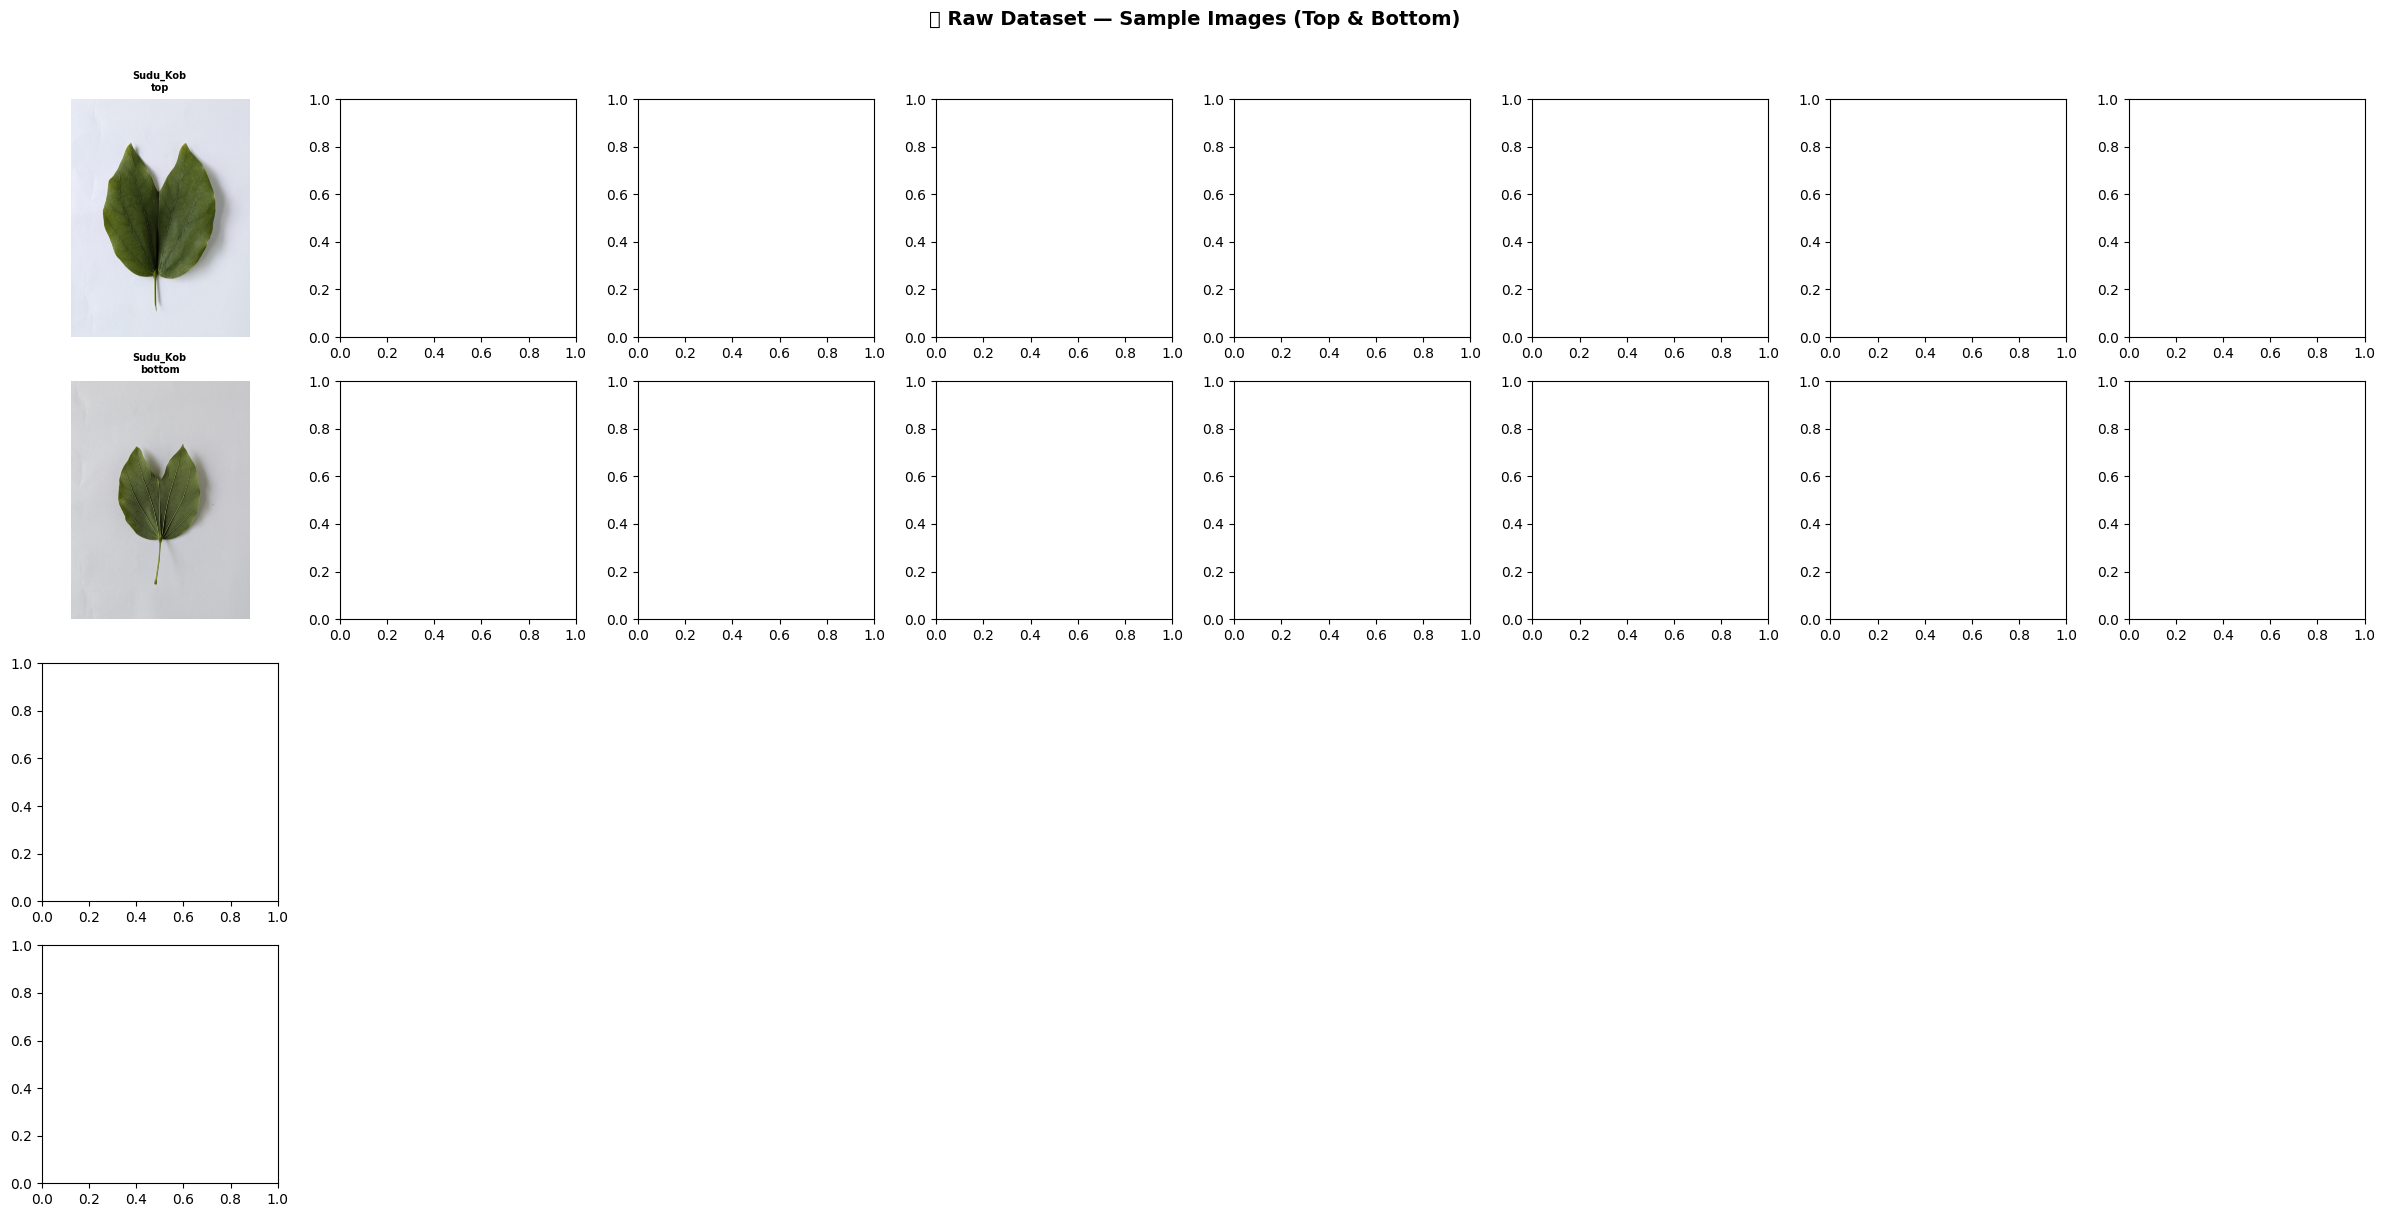

In [6]:
import cv2
import random

fig, axes = plt.subplots(4, 8, figsize=(24, 12))

for col, species in enumerate(SPECIES_LIST):
    for row, view in enumerate(['top', 'bottom']):
        imgs = glob(os.path.join(RAW_PATH, species, view, '*.jpg')) + \
               glob(os.path.join(RAW_PATH, species, view, '*.jpeg')) + \
               glob(os.path.join(RAW_PATH, species, view, '*.png'))
        ax = axes[row * 2][col] if row == 0 else axes[row * 2][col]
        ax = axes[row][col] if row < 2 else axes[row + 1][col]
        if imgs:
            img = cv2.imread(random.choice(imgs))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row][col].imshow(img)
        axes[row][col].set_title(
            f'{species[:8]}\n{view}', fontsize=7, fontweight='bold')
        axes[row][col].axis('off')

# Hide unused rows
for col in range(len(SPECIES_LIST), 8):
    axes[2][col].axis('off')
    axes[3][col].axis('off')

plt.suptitle('🌿 Raw Dataset — Sample Images (Top & Bottom)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/01_raw_samples.png', bbox_inches='tight', dpi=120)
plt.show()
print('✅ Sample grid saved!')

## Step 5 — Generate species_labels.csv

In [7]:
records = []

for pair_idx, (sp_a, sp_b) in enumerate(SPECIES_PAIRS, 1):
    for species in [sp_a, sp_b]:
        for view in VIEWS:
            imgs = glob(os.path.join(RAW_PATH, species, view, '*.jpg'))  + \
                   glob(os.path.join(RAW_PATH, species, view, '*.jpeg')) + \
                   glob(os.path.join(RAW_PATH, species, view, '*.png'))
            for img_path in sorted(imgs):
                records.append({
                    'image_path'    : img_path,
                    'species_label' : species,   # used for model training
                    'view_side'     : view,       # metadata only
                    'pair_id'       : pair_idx,   # metadata only
                    'split'         : 'unassigned' # assigned in notebook 05
                })

df = pd.DataFrame(records)

# Save
os.makedirs(LABELS_PATH, exist_ok=True)
csv_path = os.path.join(LABELS_PATH, 'species_labels.csv')
df.to_csv(csv_path, index=False)

print('✅ species_labels.csv created!')
print(f'   Total images : {len(df)}')
print(f'   Species      : {df.species_label.nunique()}')
print(f'   Top images   : {len(df[df.view_side=="top"])}')
print(f'   Bottom images: {len(df[df.view_side=="bottom"])}')
print(f'   Saved to     : {csv_path}')
print()
print(df.head(10).to_string(index=False))

✅ species_labels.csv created!
   Total images : 116
   Species      : 1
   Top images   : 58
   Bottom images: 58
   Saved to     : /content/drive/MyDrive/VedaVision/dataset/labels/species_labels.csv

                                                                                 image_path  species_label view_side  pair_id      split
/content/drive/MyDrive/VedaVision/dataset/raw/Sudu_Koboleela/top/PXL_20260506_083718268.jpg Sudu_Koboleela       top        1 unassigned
/content/drive/MyDrive/VedaVision/dataset/raw/Sudu_Koboleela/top/PXL_20260506_083754731.jpg Sudu_Koboleela       top        1 unassigned
/content/drive/MyDrive/VedaVision/dataset/raw/Sudu_Koboleela/top/PXL_20260506_083837276.jpg Sudu_Koboleela       top        1 unassigned
/content/drive/MyDrive/VedaVision/dataset/raw/Sudu_Koboleela/top/PXL_20260506_084024098.jpg Sudu_Koboleela       top        1 unassigned
/content/drive/MyDrive/VedaVision/dataset/raw/Sudu_Koboleela/top/PXL_20260506_084050082.jpg Sudu_Koboleela       t

## Step 6 — Image Count Bar Chart

/tmp/ipykernel_20935/984114208.py:24: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20935/984114208.py:25: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{LOGS_PATH}/01_image_counts.png', bbox_inches='tight', dpi=150)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/VedaVision/dataset/logs/01_image_counts.png'

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


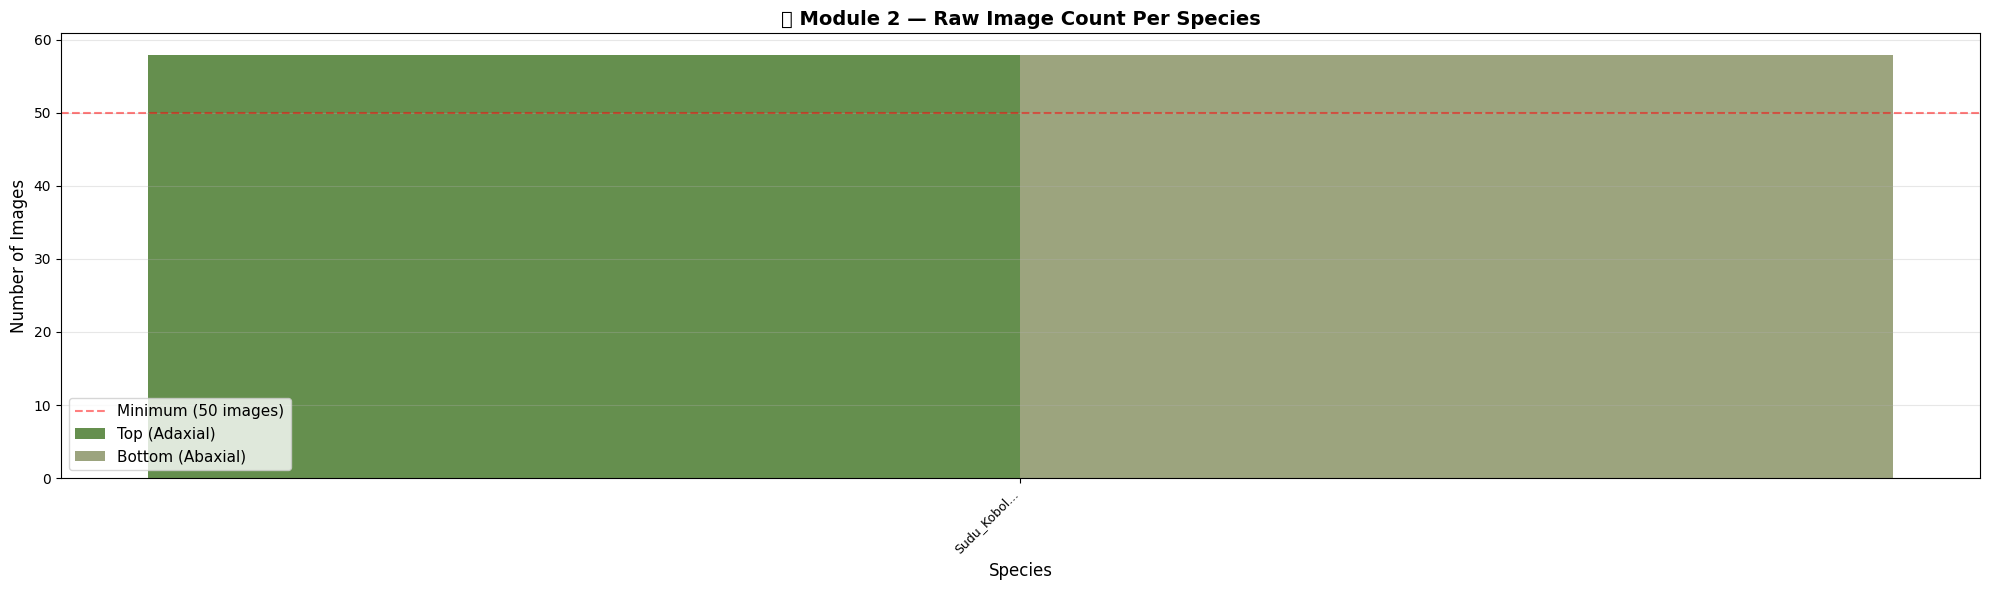

In [9]:
summary_df = pd.DataFrame(summary)
x     = np.arange(len(SPECIES_LIST))
width = 0.35

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(x - width/2, summary_df.top_count, width,
       label='Top (Adaxial)',    color='#4A7C2F', alpha=0.85)
ax.bar(x + width/2, summary_df.bot_count, width,
       label='Bottom (Abaxial)', color='#8B9467', alpha=0.85)
ax.axhline(y=50, color='red', linestyle='--',
           alpha=0.5, label='Minimum (50 images)')

ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('🌿 Module 2 — Raw Image Count Per Species',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(
    [s[:10]+'...' if len(s)>10 else s for s in SPECIES_LIST],
    rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/01_image_counts.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Chart saved!')
print()
print('📋 Next step: Run 02_augmentation.ipynb')